# MaldiAMRKit - Exploration & Similarity

This notebook demonstrates how to use MaldiAMRKit's exploratory visualisation
and spectral similarity functions to inspect MALDI-TOF datasets before building
classifiers.

It covers:
- **PCA** scatter plots coloured by metadata
- **t-SNE** embeddings
- **UMAP** embeddings (requires `pip install maldiamrkit[batch]`)
- **Spectral similarity**: pairwise distance matrices, heatmaps, clustering, and dendrograms
- Brief introduction to **batch effect correction** with `combatlearn`

## Dataset

This notebook uses the **full multi-site** version of the **MALDI-Kleb-AI** dataset (Rocchi *et al.*, 2026; [Zenodo DOI 10.5281/zenodo.17405072](https://zenodo.org/records/17405072)) - all three Italian centres (Rome, Milan, Catania), about 770 spectra. The other notebooks restrict themselves to the Rome sub-cohort, but exploration is precisely where you *want* the full multi-centre cohort: unsupervised methods will quickly tell you whether site / batch effects dominate the resistance signal. The helper in [`notebooks/_demo.py`](_demo.py) caches the 370 MB tarball under `~/.cache/maldiamrkit/` on first use.

In [1]:
import pathlib
import sys

from maldiamrkit.visualization import plot_pca, plot_tsne

sys.path.insert(0, str(pathlib.Path.cwd()))  # _demo.py sits next to this notebook
from _demo import load_maldi_kleb_ai

/home/ettore/.venvs/maldiamrkit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the Dataset

Exploration is the one notebook where the full multi-site cohort is
more interesting than the Rome-only slice: with three acquisition
centres (Rome, Milan, Catania) we can see whether unsupervised
structure tracks the resistance phenotype or the acquisition site.
Pass ``city=None`` to load all three centres.

In [2]:
ds = load_maldi_kleb_ai(antibiotic="Amikacin", city=None, verbose=True)
data = ds.maldi_set
labels = ds.meta["Amikacin"]
sites = ds.meta["City"]
print(f"Samples: {ds.X.shape[0]}, Features: {ds.X.shape[1]}")
print(f"Labels: {labels.value_counts().to_dict()}")
print(f"Sites:  {sites.value_counts().to_dict()}")

Processing spectra:   0%|          | 0/743 [00:00<?, ?spectrum/s]

Processing spectra:  61%|██████▏   | 456/743 [00:00<00:00, 4551.60spectrum/s]

Processing spectra: 100%|██████████| 743/743 [00:00<00:00, 4637.49spectrum/s]

Samples: 741, Features: 6000
Labels: {'S': 372, 'R': 369}
Sites:  {'Rome': 470, 'Milan': 184, 'Catania': 87}


## PCA

PCA is the simplest starting point. Axis labels automatically show
the explained variance percentage.

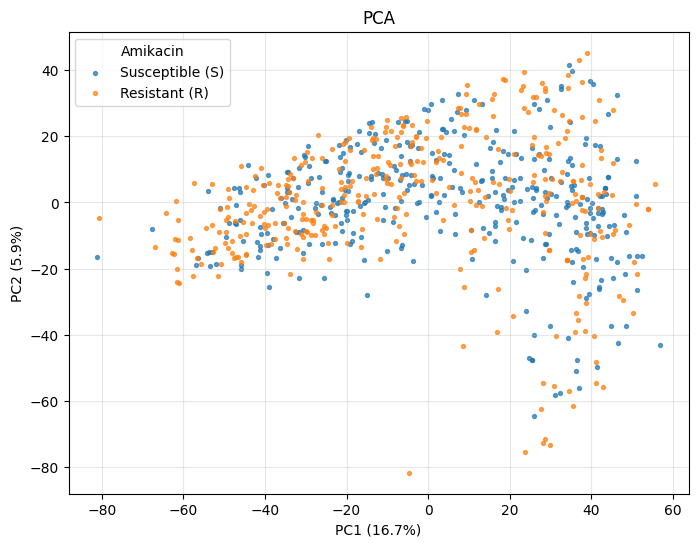

In [3]:
_ = plot_pca(ds.X, color_by=labels)

You can pass any matplotlib keyword arguments through `**pca_kwargs`,
or provide a custom palette:

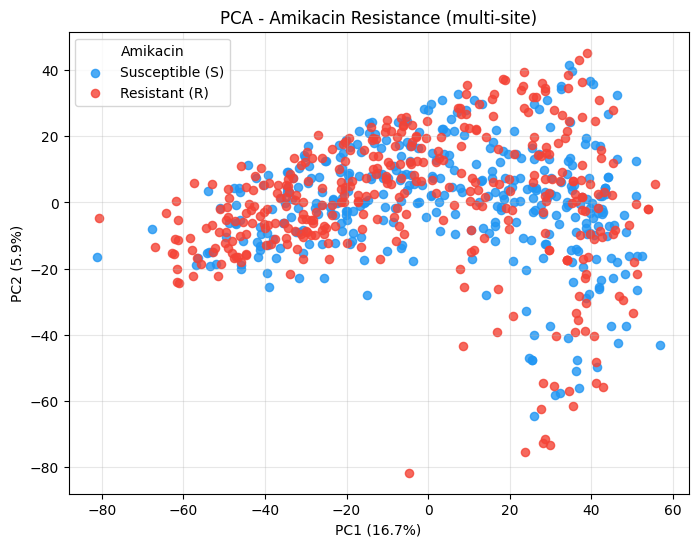

In [4]:
_ = plot_pca(
    ds.X,
    color_by=labels,
    palette={"S": "#2196F3", "R": "#F44336"},
    title="PCA - Amikacin Resistance (multi-site)",
    alpha=0.8,
    s=35,
)

Now colour by the acquisition centre instead - if the three sites
separate, you are seeing batch / instrument effects rather than
biology, and the unsupervised plots are not telling you about
resistance.

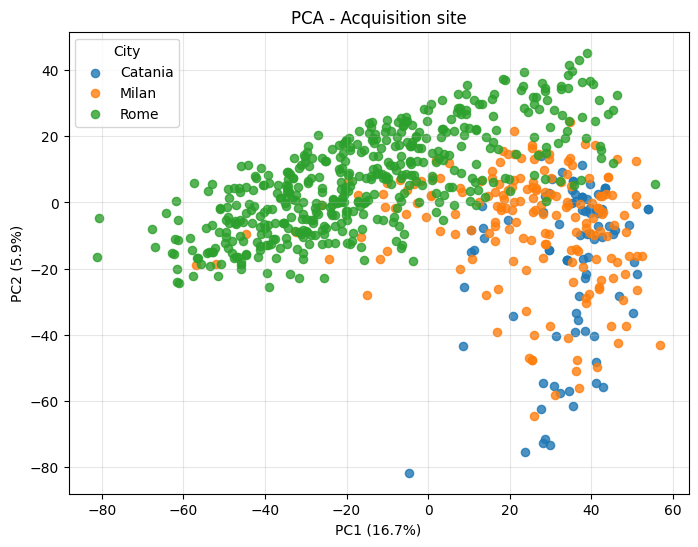

In [5]:
_ = plot_pca(
    ds.X,
    color_by=sites,
    title="PCA - Acquisition site",
    alpha=0.8,
    s=35,
)

## t-SNE

For a non-linear embedding, use `plot_tsne`. With ~470 samples,
perplexity in the 20-40 range is a reasonable default.

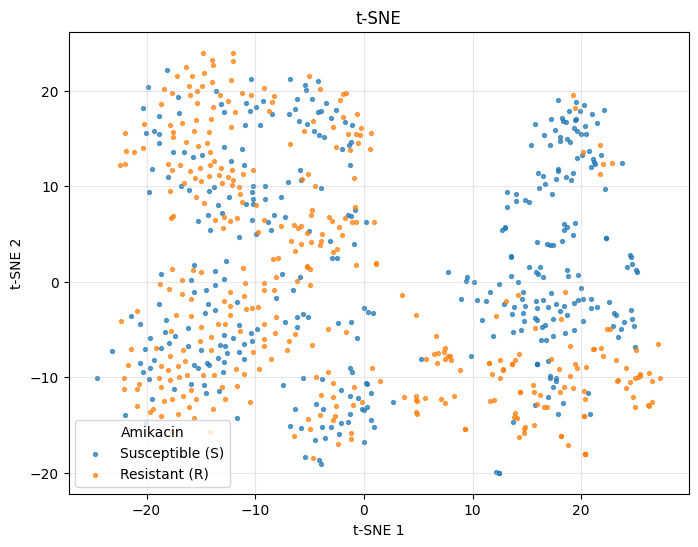

In [6]:
_ = plot_tsne(ds.X, color_by=labels, perplexity=30, random_state=42)

## UMAP

UMAP requires the optional `umap-learn` package:

```bash
pip install maldiamrkit[batch]
```

/home/ettore/.venvs/maldiamrkit/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


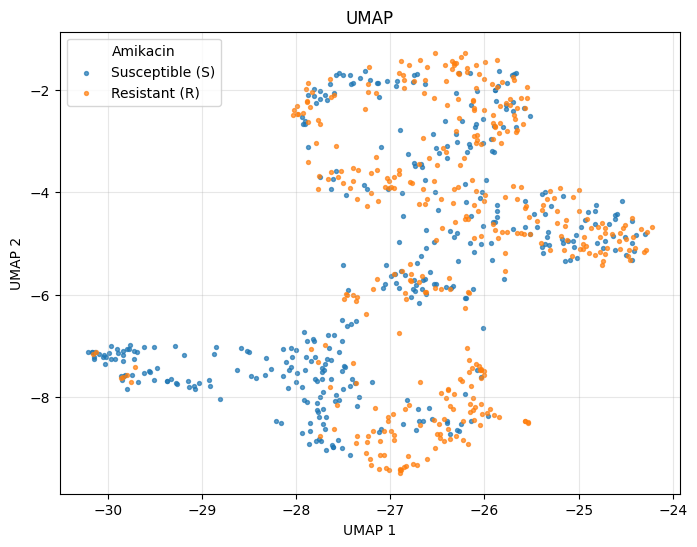

In [7]:
try:
    from maldiamrkit.visualization import plot_umap

    _ = plot_umap(ds.X, color_by=labels, n_neighbors=15, random_state=42)
except ImportError as e:
    print(e)

## Spectral Similarity

MaldiAMRKit provides spectral distance metrics, pairwise distance matrix
computation, clustering algorithms, and dedicated plots for similarity
analysis.

Available metrics (see `SpectralMetric`):
- **cosine** - cosine distance (binned spectra)
- **spectral_contrast_angle** - spectral contrast angle (binned spectra)
- **pearson** - 1 - Pearson correlation (binned spectra)
- **wasserstein** - Wasserstein / earth mover's distance (raw spectra)
- **dtw** - dynamic time warping distance (raw spectra)

For the pairwise heatmap and dendrogram we subsample to keep the figures
readable; the same calls scale to the full 470-spectrum matrix.

In [8]:
from maldiamrkit.similarity import (
    cluster_metadata_concordance,
    cluster_spectra,
    hierarchical_clustering,
    pairwise_distances,
    plot_dendrogram,
    plot_distance_heatmap,
    silhouette_scores,
)

### Pairwise Distance Matrix

Compute a symmetric distance matrix from the binned feature matrix.
For binned spectra, cosine distance is a natural choice.

In [9]:
import numpy as np

rng = np.random.default_rng(0)
subset_idx = rng.choice(ds.X.shape[0], size=80, replace=False)
X_subset = ds.X.iloc[subset_idx]
labels_subset = labels.iloc[subset_idx]

D = pairwise_distances(X_subset, metric="cosine")
print(f"Distance matrix shape: {D.shape}")
print(f"Range: [{D[D > 0].min():.4f}, {D.max():.4f}]")

Distance matrix shape: (80, 80)
Range: [0.0449, 0.8068]


### Distance Heatmap

Visualise the pairwise distance matrix. Darker values indicate more
similar spectra.

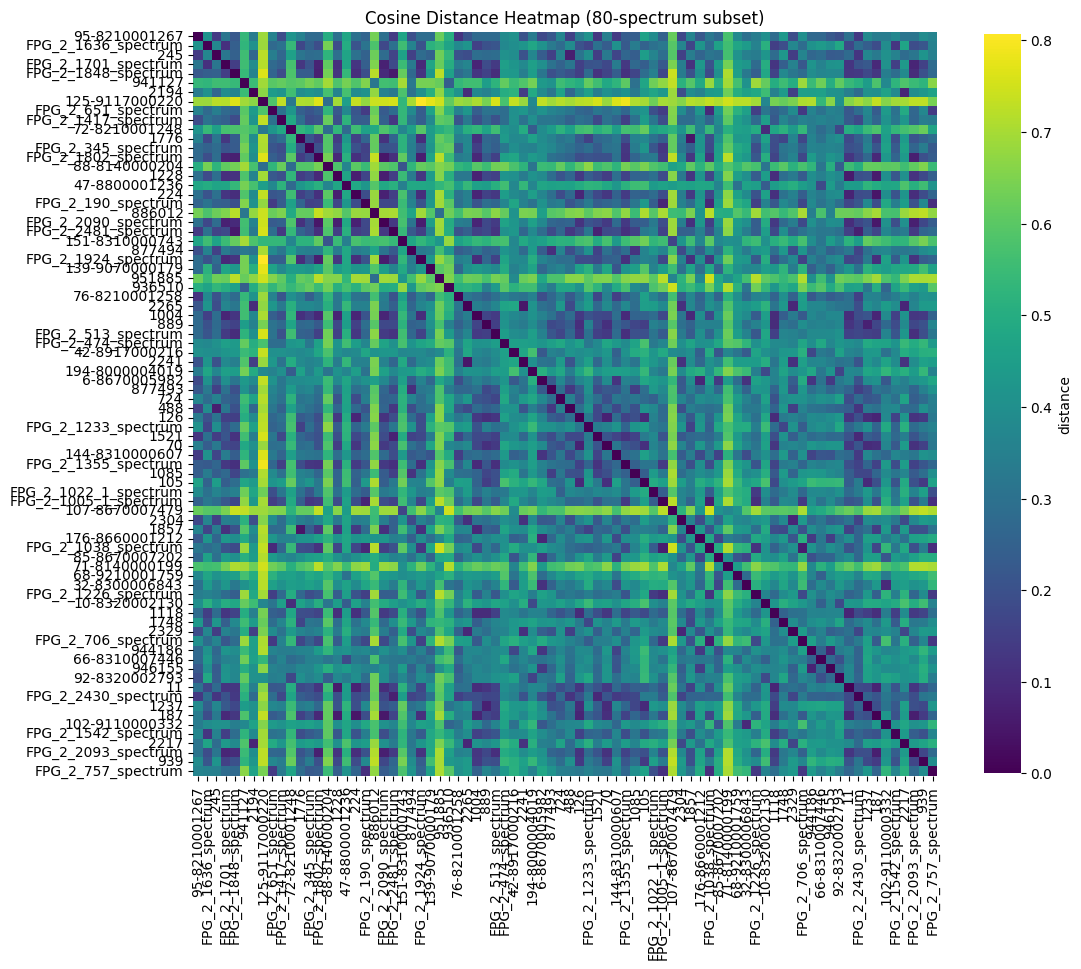

In [10]:
_ = plot_distance_heatmap(
    D,
    labels=X_subset.index.tolist(),
    title="Cosine Distance Heatmap (80-spectrum subset)",
)

### Hierarchical Clustering & Dendrogram

Build a linkage matrix and visualise the cluster hierarchy.

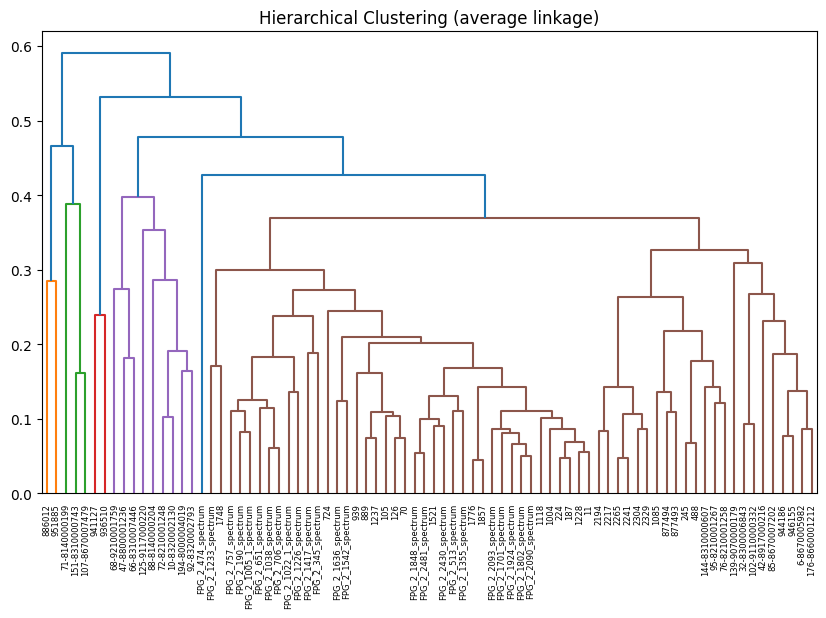

In [11]:
linkage = hierarchical_clustering(D, method="average")
_ = plot_dendrogram(
    linkage,
    labels=X_subset.index.tolist(),
    title="Hierarchical Clustering (average linkage)",
)

### Cluster Assignment & Evaluation

Use `cluster_spectra` for a one-call clustering workflow. We ask for
**three clusters** - matching the three acquisition centres - and
then score the partition against both the resistance phenotype and
the site label with silhouette scores and metadata concordance (ARI,
NMI). This is a clean diagnostic: if clusters track the *site* but
not the *phenotype*, batch effects are dominating the unsupervised
signal - a classic motivator for ComBat-style correction.

We use `method='kmedoids'` here: with very uneven cluster sizes
(Rome alone is ~470 spectra) average-linkage hierarchical clustering
tends to peel off a couple of singletons instead of recovering the
three centres. K-medoids respects the requested cluster count and
produces balanced groups that closely match the site labels.

In [12]:
import pandas as pd

D_full = pairwise_distances(ds.X, metric="cosine")
cluster_labels = cluster_spectra(
    D_full,
    method="kmedoids",
    n_clusters=3,
    random_state=42,
)

sil = silhouette_scores(D_full, cluster_labels)
print(f"Silhouette score:               {sil:.3f}")

conc_pheno = cluster_metadata_concordance(cluster_labels, labels)
print("\nConcordance vs. Amikacin (R/S):")
print(f"  Adjusted Rand Index:          {conc_pheno['adjusted_rand_index']:.3f}")
print(f"  Normalized Mutual Info:       {conc_pheno['normalized_mutual_info']:.3f}")

conc_site = cluster_metadata_concordance(cluster_labels, sites)
print("\nConcordance vs. acquisition site (City):")
print(f"  Adjusted Rand Index:          {conc_site['adjusted_rand_index']:.3f}")
print(f"  Normalized Mutual Info:       {conc_site['normalized_mutual_info']:.3f}")

print("\nClusters x City:")
pd.crosstab(
    pd.Series(cluster_labels, index=sites.index, name="Cluster"),
    sites,
)

Silhouette score:               0.294

Concordance vs. Amikacin (R/S):
  Adjusted Rand Index:          0.029
  Normalized Mutual Info:       0.042

Concordance vs. acquisition site (City):
  Adjusted Rand Index:          0.688
  Normalized Mutual Info:       0.541

Clusters x City:


City,Catania,Milan,Rome
Cluster,,,
0,7,7,439
1,80,110,21
2,0,67,10


### Comparing Metrics

Try different distance metrics to see which one recovers the site
structure most cleanly. We compare each metric against both the
resistance phenotype and the acquisition site.

In [13]:
results = []
for metric in ["cosine", "spectral_contrast_angle", "pearson"]:
    D_m = pairwise_distances(ds.X, metric=metric)
    cl = cluster_spectra(D_m, method="kmedoids", n_clusters=3, random_state=42)
    sil_m = silhouette_scores(D_m, cl)
    conc_pheno = cluster_metadata_concordance(cl, labels)
    conc_site = cluster_metadata_concordance(cl, sites)
    results.append(
        {
            "metric": metric,
            "silhouette": sil_m,
            "ARI_pheno": conc_pheno["adjusted_rand_index"],
            "NMI_pheno": conc_pheno["normalized_mutual_info"],
            "ARI_site": conc_site["adjusted_rand_index"],
            "NMI_site": conc_site["normalized_mutual_info"],
        }
    )

pd.DataFrame(results).set_index("metric")

,silhouette,ARI_pheno,NMI_pheno,ARI_site,NMI_site
metric,,,,,
cosine,0.294047,0.029394,0.041665,0.687924,0.541444
spectral_contrast_angle,0.152448,0.019211,0.016085,0.449982,0.410990
pearson,0.250229,0.016489,0.013949,0.391881,0.361815


## Batch Effect Correction

When combining data from multiple sites or instruments, batch effects
can dominate the signal. MaldiAMRKit on its own focuses on the single-
site case (that is why this notebook restricts to Rome). For multi-
centre harmonisation use
[combatlearn](https://github.com/EttoreRocchi/combatlearn) directly,
or use the dedicated
[MaldiBatchKit](https://github.com/EttoreRocchi/MaldiBatchKit) sister
package which builds on top of it:

```python
from combatlearn import Combat

combat = Combat(method='fortin')
combat.fit(X, y=batch_labels)
X_corrected = combat.transform(X, y=batch_labels)
```

Install with `pip install maldiamrkit[batch]`.
See the [combatlearn documentation](https://combatlearn.readthedocs.io/)
for full usage.

> Rocchi, E., Nicitra, E., Calvo, M. et al. *Combining mass spectrometry
> and machine learning models for predicting Klebsiella pneumoniae
> antimicrobial resistance: a multicenter experience from clinical
> isolates in Italy*. **BMC Microbiol** (2026).
> [doi:10.1186/s12866-025-04657-2](https://link.springer.com/article/10.1186/s12866-025-04657-2)